# D5 — Developer Community Map (Leiden)

Reads Leiden community assignments from GCS and produces:
- Community size distribution
- Top communities by aggregate PageRank
- Intra-community degree analysis
- Community membership table

> **Privacy note**: developer identities are SHA-256 hashed; raw emails are never stored or displayed.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '../service-account-key.json'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

BUCKET = 'github-tech-trends-data'
sns.set_theme(style='whitegrid')
print('Environment ready.')

Environment ready.


## 1. Load data

In [2]:
df = pd.read_parquet(f'gs://{BUCKET}/processed/d5_communities/')
print(f'Developers: {len(df):,}')
print('Columns:', df.columns.tolist())

n_communities = df['community_id'].nunique()
print(f'Communities detected: {n_communities}')
df.head(5)

Developers: 10,000
Columns: ['dev_id', 'community_id', 'pagerank', 'degree']
Communities detected: 641


,dev_id,community_id,pagerank,degree
0,0009b72a02997374373565dbf0d65abc9b037f726ba830...,0,0.000041,32
1,00165af9cf528dc70997122def8c1686a5359b0e46b228...,1,0.000098,1509
2,001cb72943c7a1455b1db5ca40980493afb761e12be1ca...,7,0.000115,64
3,002078f17892e31746cd98153f3b6b573c48e0096ddc52...,0,0.000071,20
4,002d7bea94dc000625eb1ae53ca734148351d4ba6a2ae2...,3,0.000019,5


In [ ]:
import hashlib

def sha256(email):
    return hashlib.sha256(email.strip().lower().encode()).hexdigest()

# Load raw developer-repo edges and hash emails to match community dev_id
raw_devs = pd.read_parquet(f'gs://{BUCKET}/raw/developers/')
raw_devs['dev_id'] = raw_devs['developer_email'].apply(sha256)
raw_devs = raw_devs.drop(columns=['developer_email'])

# Join community assignments with repo contributions
dev_comm = df[['dev_id', 'community_id']].merge(raw_devs, on='dev_id', how='inner')

# For each community find top repos by total commits
repo_by_comm = (
    dev_comm.groupby(['community_id', 'repo_name'])['commit_count']
    .sum()
    .reset_index()
)

def top_orgs(group, n=3):
    top = group.nlargest(n, 'commit_count')['repo_name']
    orgs = [r.split('/')[0] for r in top]
    # deduplicate while preserving order
    seen = set()
    unique = [o for o in orgs if not (o in seen or seen.add(o))]
    return ', '.join(unique[:n])

comm_labels = (
    repo_by_comm.groupby('community_id')
    .apply(top_orgs)
    .reset_index()
    .rename(columns={0: 'top_orgs'})
)

print('Sample community labels:')
print(comm_labels.head(10).to_string(index=False))

## 2. Community size distribution

In [ ]:
community_sizes = df.groupby('community_id').size().sort_values(ascending=False)

print(f'Largest community : {community_sizes.iloc[0]:,} members')
print(f'Median comm. size : {community_sizes.median():.0f} members')
print(f'Singleton comms   : {(community_sizes == 1).sum()}')

# Build display labels: "C0 (microsoft, google, ...)"
label_map = comm_labels.set_index('community_id')['top_orgs'].to_dict()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.hist(community_sizes.values, bins=50, color='steelblue',
         edgecolor='white', linewidth=0.3, log=True)
ax1.set_xlabel('Community Size (members)')
ax1.set_ylabel('Count (log scale)')
ax1.set_title('Community Size Distribution', fontsize=11, fontweight='bold')

top20_sizes = community_sizes.head(20)
tick_labels = [
    f'C{c}\n({label_map.get(c, "?")})' for c in top20_sizes.index
]
ax2.bar(range(len(top20_sizes)), top20_sizes.values,
        color=sns.color_palette('viridis', len(top20_sizes)))
ax2.set_xticks(range(len(top20_sizes)))
ax2.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
ax2.set_xlabel('Community (top contributing orgs)')
ax2.set_ylabel('Members')
ax2.set_title('Top 20 Largest Communities', fontsize=11, fontweight='bold')

plt.suptitle('Leiden Community Structure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d5_community_sizes.png', dpi=150)
plt.show()

## 3. Community influence — aggregate PageRank

In [ ]:
comm_stats = (
    df.groupby('community_id')
    .agg(
        size=('dev_id', 'count'),
        total_pagerank=('pagerank', 'sum'),
        mean_pagerank=('pagerank', 'mean'),
        max_pagerank=('pagerank', 'max'),
        mean_degree=('degree', 'mean'),
    )
    .sort_values('total_pagerank', ascending=False)
    .reset_index()
)

# Attach ecosystem labels
comm_stats = comm_stats.merge(comm_labels, on='community_id', how='left')
comm_stats['display_label'] = comm_stats.apply(
    lambda r: f"C{r['community_id']} ({r['top_orgs']})", axis=1
)

top15 = comm_stats.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.barh(top15['display_label'], top15['total_pagerank'],
         color=sns.color_palette('Blues_r', 15))
ax1.invert_yaxis()
ax1.set_xlabel('Total PageRank (sum)')
ax1.set_title('Top 15 Communities by Total Influence', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelsize=8)

ax2.barh(top15['display_label'], top15['mean_pagerank'],
         color=sns.color_palette('Oranges_r', 15))
ax2.invert_yaxis()
ax2.set_xlabel('Mean PageRank (per member)')
ax2.set_title('Top 15 Communities by Mean Influence', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelsize=8)

plt.suptitle('Community Influence Rankings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d5_community_influence.png', dpi=150)
plt.show()

## 4. Size vs Influence bubble chart

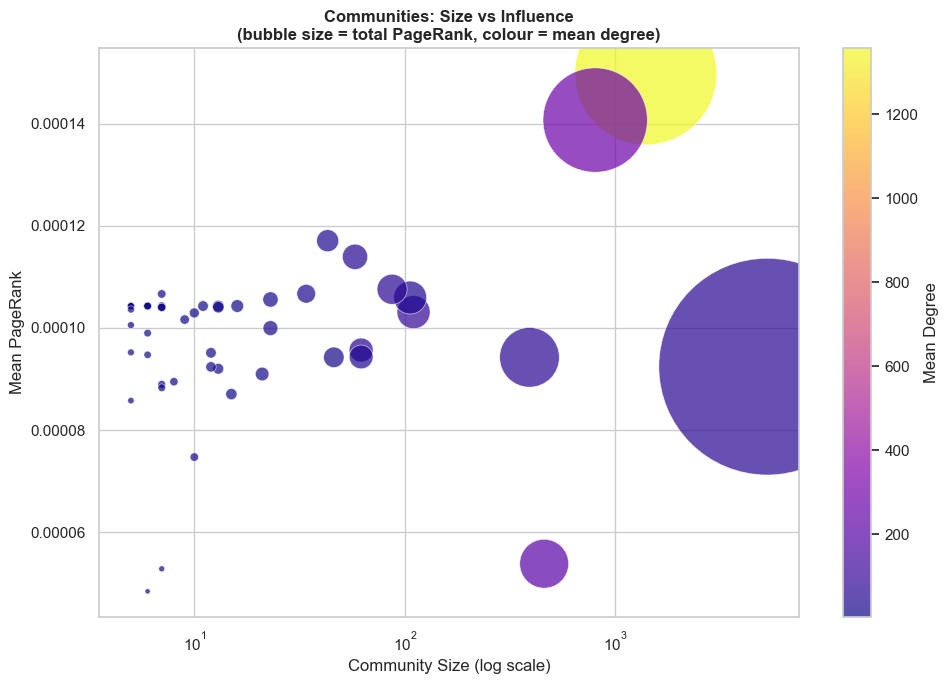

In [5]:
# Only communities with ≥5 members
big = comm_stats[comm_stats['size'] >= 5].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    big['size'], big['mean_pagerank'],
    s=big['total_pagerank'] * 5e4,
    c=big['mean_degree'], cmap='plasma',
    alpha=0.7, edgecolors='white', linewidths=0.5,
)
plt.colorbar(scatter, ax=ax, label='Mean Degree')
ax.set_xscale('log')
ax.set_xlabel('Community Size (log scale)')
ax.set_ylabel('Mean PageRank')
ax.set_title('Communities: Size vs Influence\n'
             '(bubble size = total PageRank, colour = mean degree)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d5_size_vs_influence.png', dpi=150)
plt.show()

## 5. Community composition heatmap (degree × PageRank)

In [ ]:
df['degree_q'] = pd.qcut(df['degree'], q=4,
                          labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])

top10_comms = comm_stats.head(10)['community_id'].tolist()
heat_df = df[df['community_id'].isin(top10_comms)].copy()

# Replace numeric community_id with readable label
heat_df['community_label'] = heat_df['community_id'].map(
    comm_stats.set_index('community_id')['display_label']
)

pivot = (
    heat_df.groupby(['community_label', 'degree_q'])
    .size()
    .unstack('degree_q')
    .fillna(0)
)

# Sort by total pagerank order (same as comm_stats top10)
label_order = comm_stats.head(10)['display_label'].tolist()
pivot = pivot.reindex([l for l in label_order if l in pivot.index])

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Top 10 Communities — Degree Quartile Breakdown',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Degree Quartile')
ax.set_ylabel('Community (top contributing orgs)')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('../outputs/d5_community_heatmap.png', dpi=150)
plt.show()

## 6. Community stats summary table

In [ ]:
display_cols = ['display_label', 'size', 'total_pagerank',
                'mean_pagerank', 'max_pagerank', 'mean_degree']

comm_stats[display_cols].head(20).rename(columns={
    'display_label': 'community',
    'size': 'members',
    'total_pagerank': 'total_PR',
    'mean_pagerank': 'mean_PR',
    'max_pagerank': 'max_PR',
    'mean_degree': 'mean_degree',
}).style \
    .background_gradient(subset=['total_PR', 'mean_PR'], cmap='Blues') \
    .background_gradient(subset=['members'], cmap='Greens') \
    .format({'total_PR': '{:.6f}', 'mean_PR': '{:.8f}',
             'max_PR': '{:.8f}', 'mean_degree': '{:.1f}'})